<a href="https://colab.research.google.com/github/ramzanr12/Age-prediction/blob/Ramzan/data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import userdata
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [4]:
# Colab cell 2 - kaggle CLI install & verify
!pip install -q kaggle
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [5]:
!kaggle datasets download -d mariafrenti/age-prediction -p /content/data

Dataset URL: https://www.kaggle.com/datasets/mariafrenti/age-prediction
License(s): unknown
100% 2.03G/2.03G [00:28<00:00, 77.5MB/s]



In [6]:
!unzip -q /content/data/age-prediction.zip -d /content/data/age-prediction

In [7]:
import os

root = '/content/data/age-prediction'
for dirpath, dirnames, filenames in os.walk(root):
    level = dirpath.replace(root, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(dirpath)}/  -> {len(filenames)} files')
    if level > 2:
        break

age-prediction/  -> 0 files
  age_prediction_up/  -> 0 files
    age_prediction/  -> 0 files
      train/  -> 0 files


In [8]:
import os

root = '/content/data/age-prediction'
for dirpath, dirnames, filenames in os.walk(root):
    level = dirpath.replace(root, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(dirpath)}/  -> {len(filenames)} files')
    if level > 5:   # depth kootiruken
        break

age-prediction/  -> 0 files
  age_prediction_up/  -> 0 files
    age_prediction/  -> 0 files
      train/  -> 0 files
        044/  -> 3492 files
        097/  -> 8 files
        015/  -> 893 files
        022/  -> 3749 files
        014/  -> 709 files
        093/  -> 24 files
        030/  -> 5994 files
        036/  -> 5699 files
        020/  -> 3125 files
        063/  -> 1058 files
        049/  -> 2687 files
        053/  -> 2077 files
        058/  -> 1472 files
        024/  -> 4846 files
        034/  -> 5587 files
        075/  -> 377 files
        092/  -> 36 files
        028/  -> 5352 files
        027/  -> 5915 files
        006/  -> 97 files
        047/  -> 2873 files
        080/  -> 270 files
        085/  -> 198 files
        078/  -> 283 files
        072/  -> 508 files
        050/  -> 2366 files
        039/  -> 5406 files
        025/  -> 5488 files
        074/  -> 327 files
        031/  -> 6790 files
        037/  -> 4969 files
        086/  -> 101 files
    

In [9]:
import os
import pandas as pd

train_root = '/content/data/age-prediction/age_prediction_up/age_prediction/train'
test_root = '/content/data/age-prediction/age_prediction_up/age_prediction/test'

def build_df(root_dir):
    data = []
    for age_folder in os.listdir(root_dir):
        folder_path = os.path.join(root_dir, age_folder)
        if not os.path.isdir(folder_path):
            continue
        age = int(age_folder)  # '044' -> 44
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({
                    'filepath': os.path.join(folder_path, fname),
                    'age': age
                })
    return pd.DataFrame(data)

train_df = build_df(train_root)
test_df = build_df(test_root)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()

Train: (185632, 2)
Test: (47568, 2)


,filepath,age
0,/content/data/age-prediction/age_prediction_up...,44
1,/content/data/age-prediction/age_prediction_up...,44
2,/content/data/age-prediction/age_prediction_up...,44
3,/content/data/age-prediction/age_prediction_up...,44
4,/content/data/age-prediction/age_prediction_up...,44


In [10]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (167068, 2)
Val: (18564, 2)
Test: (47568, 2)


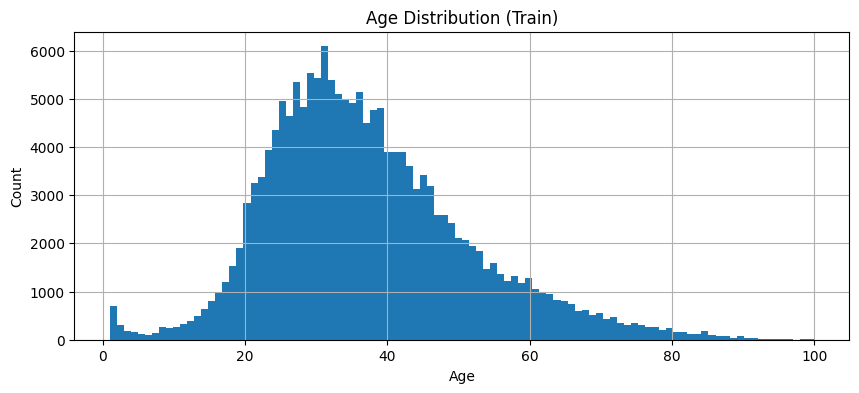

count    167068.000000
mean         37.141912
std          14.327151
min           1.000000
25%          27.000000
50%          35.000000
75%          45.000000
max         100.000000
Name: age, dtype: float64


In [11]:
import matplotlib.pyplot as plt

train_df['age'].hist(bins=100, figsize=(10,4))
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution (Train)')
plt.show()

print(train_df['age'].describe())

In [12]:
!pip install -q tqdm

In [13]:
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import os

def check_image(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        return (filepath, True)
    except Exception:
        return (filepath, False)

def check_all_images(df, desc="Checking"):
    filepaths = df['filepath'].tolist()
    results = []

    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = {executor.submit(check_image, fp): fp for fp in filepaths}
        for future in tqdm(as_completed(futures), total=len(futures), desc=desc):
            results.append(future.result())

    result_df = pd.DataFrame(results, columns=['filepath', 'is_valid'])
    return result_df

In [14]:
train_check = check_all_images(train_df, desc="Train")
val_check = check_all_images(val_df, desc="Val")
test_check = check_all_images(test_df, desc="Test")

Test: 100%|██████████| 47568/47568 [00:10<00:00, 4326.47it/s]


In [15]:
def get_valid_df(original_df, check_df):
    valid_paths = set(check_df[check_df['is_valid']]['filepath'])
    return original_df[original_df['filepath'].isin(valid_paths)].reset_index(drop=True)

train_df_clean = get_valid_df(train_df, train_check)
val_df_clean = get_valid_df(val_df, val_check)
test_df_clean = get_valid_df(test_df, test_check)

print("Before -> After cleaning:")
print(f"Train: {len(train_df)} -> {len(train_df_clean)}")
print(f"Val:   {len(val_df)} -> {len(val_df_clean)}")
print(f"Test:  {len(test_df)} -> {len(test_df_clean)}")

Before -> After cleaning:
Train: 167068 -> 167068
Val:   18564 -> 18564
Test:  47568 -> 47568


In [19]:
def load_and_preprocess(path, age):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, age

def make_dataset(df, training=False):
    paths = df['filepath'].values
    ages = df['age'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, ages))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(2000)
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda x, y: (tf.image.random_brightness(x, 0.1), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        # brightness apram range mudhinjidum, adha clip pannu
        ds = ds.map(lambda x, y: (tf.clip_by_value(x, 0.0, 1.0), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df_clean, training=True)
val_ds = make_dataset(val_df_clean)
test_ds = make_dataset(test_df_clean)

Batch shape: (32, 128, 128, 3)
Ages shape: (32,)


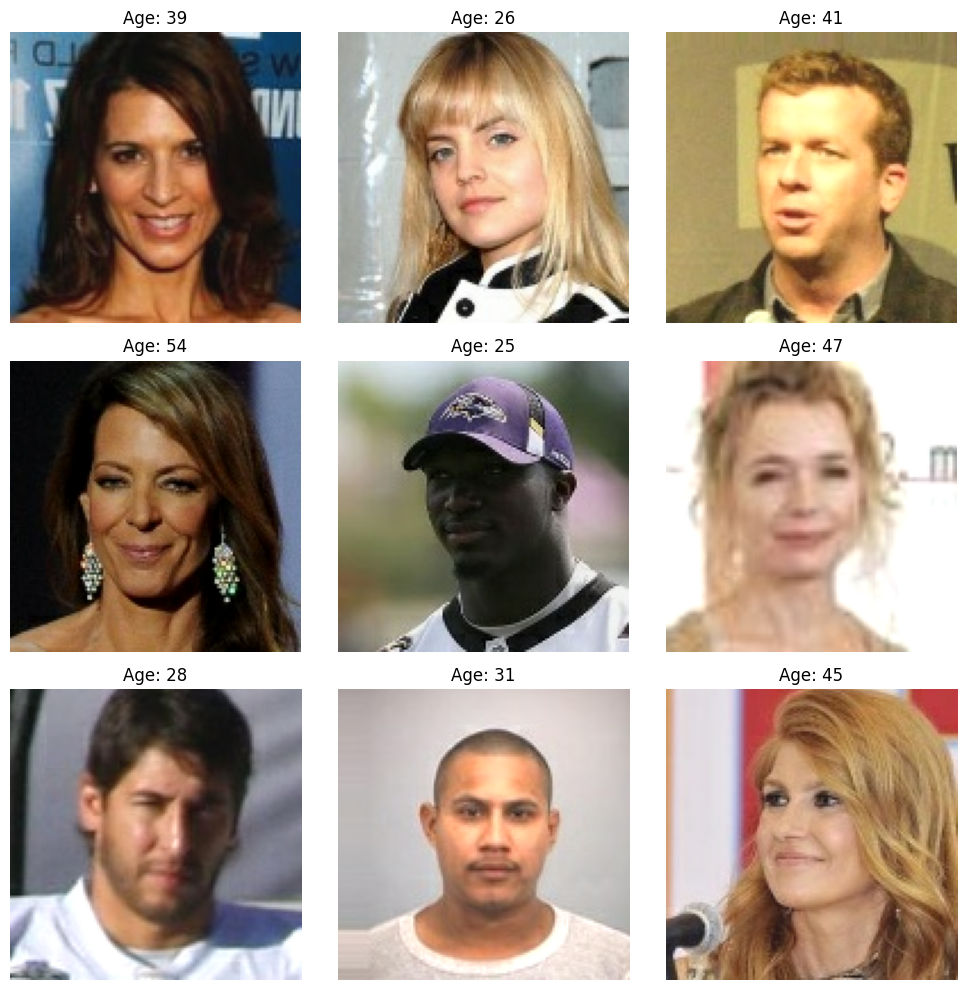

In [20]:
import matplotlib.pyplot as plt

for images, ages in train_ds.take(1):
    print("Batch shape:", images.shape)
    print("Ages shape:", ages.shape)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(f"Age: {int(ages[i])}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()